# Nonlinear Filtering

# 非线性滤波


In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

## Introduction

## 引言

The Kalman filter that we have developed uses linear equations, and so the filter can only handle linear problems. But the world is nonlinear, and so the classic filter that we have been studying to this point can have very limited utility. 

我们此前推导的卡尔曼滤波器基于线性方程，因此只能处理线性问题。然而现实世界是非线性的，所以这些经典滤波器的适用范围其实相当有限。

There can be nonlinearity in the process model. Suppose we want to track an object falling through the atmosphere. The acceleration of the object depends on the drag it encounters. Drag depends on air density, and the air density decreases with altitude. In one dimension this can be modelled with the nonlinear differential equation

非线性可能出现在过程模型中。假设要跟踪一个穿过大气层的物体，它的加速度取决于所受的阻力，而阻力又取决于空气密度，空气密度则随高度降低。在一维情形下，可用如下非线性微分方程来建模： 

$$\ddot x = \frac{0.0034ge^{-x/22000}\dot x^2}{2\beta} - g$$

A second source of nonlinearity comes from the measurements. For example, radars measure the slant range to an object, and we are typically interested in the aircraft's position over the ground. We invoke Pythagoras and get the nonlinear equation:

非线性的第二个来源是测量。例如雷达测得的是物体的斜距，而我们通常关心飞机在地面上的位置。这时用勾股定理就得到非线性方程：

$$x=\sqrt{\mathtt{slant}^2 - \mathtt{altitude}^2}$$

These facts were not lost on the early adopters of the Kalman filter. Soon after Dr. Kalman published his paper people began working on how to extend the Kalman filter for nonlinear problems. 

早期使用卡尔曼滤波器的人对此十分清楚。Kalman 发表论文后不久，人们就开始研究如何扩展它来处理非线性问题。

It is almost true to state that the only equation anyone knows how to solve is $\mathbf{Ax}=\mathbf{b}$. We only really know how to do linear algebra. I can give you any linear set of equations and you can either solve it or prove that it has no solution. 

可以说，我们唯一真正会求解的方程就是 $\mathbf{Ax}=\mathbf{b}$。我们只会做线性代数。给我任何一个线性方程组，你都能解出它，或者证明它无解。

Anyone with formal education in math or physics has spent years learning various analytic ways to solve integrals, differential equations and so on. Yet even trivial physical systems produce equations that cannot be solved analytically. I can take an equation that you are able to integrate, insert a $\log$ term, and render it insolvable. This leads to jokes about physicists stating "assume a spherical cow on a frictionless surface in a vacuum...". Without making extreme simplifications most physical problems do not have analytic solutions.

受过正规数学或物理训练的人，都要花好几年学习求解积分、微分方程等各类解析方法。然而即便再简单的物理系统，也可能导出无法解析求解的方程：我可以取一个你能积分的方程，插入一个 $\log$ 项，它就变得不可解了。这正应了那个关于物理学家的笑话——“假设真空中无摩擦平面上有一头球形奶牛……”。不做极端简化，大多数物理问题都没有解析解。

How do we do things like model airflow over an aircraft in a computer, or predict weather, or track missiles with a Kalman filter?  We retreat to what we know: $\mathbf{Ax}=\mathbf{b}$. We find some way to linearize the problem, turning it into a set of linear equations, and then use linear algebra software packages to compute an approximate solution. 

那么，我们要怎样在计算机里模拟机翼上的气流、预测天气，或用卡尔曼滤波器跟踪导弹呢？答案是退回到我们熟悉的东西：$\mathbf{Ax}=\mathbf{b}$。设法把问题线性化，化为一组线性方程，再用线性代数软件包求出近似解。

Linearizing a nonlinear problem gives us inexact answers, and in a recursive algorithm like a Kalman filter or weather tracking system these small errors can sometimes reinforce each other at each step, quickly causing the algorithm to spit out nonsense. 

线性化会带来不准确的答案。在卡尔曼滤波器、天气预报这类递归算法中，这些小误差有时会在每一步相互放大，很快就会让算法失效。

What we are about to embark upon is a difficult problem. There is not one obvious, correct, mathematically optimal solution anymore. We will be using approximations, we will be introducing errors into our computations, and we will forever be battling filters that *diverge*, that is, filters whose numerical errors overwhelm the solution. 

我们接下来要面对的问题很棘手：不再有唯一、正确且数学上最优的解。我们只能使用近似，只能接受计算中引入的误差，还要始终与*发散*的滤波器（数值误差压过解本身的滤波器）作斗争。

In the remainder of this short chapter I will illustrate the specific problems the nonlinear Kalman filter faces. You can only design a filter after understanding the particular problems the nonlinearity in your problem causes. Subsequent chapters will then teach you how to design and implement different kinds of nonlinear filters.

本章余下的部分，我将说明非线性卡尔曼滤波器面临的具体困难。只有先弄清了问题中的非线性究竟带来哪些具体麻烦，才谈得上设计滤波器。后续各章将教你如何设计和实现不同类型的非线性滤波器。


## The Problem with Nonlinearity

## 非线性带来的问题

The mathematics of the Kalman filter is beautiful in part due to the Gaussian equation being so special. It is nonlinear, but when we add and multiply them we get another Gaussian as a result. That is very rare. $\sin{x}*\sin{y}$ does not yield a $\sin$ as an output.

卡尔曼滤波器的数学之所以优美，某种程度上是因为高斯分布很特殊：它本身是非线性的，但把两个高斯相加或相乘，结果仍是高斯分布。这非常罕见——$\sin{x}*\sin{y}$ 的结果就不会还是 $\sin$。

What I mean by linearity may be obvious, but there are some subtleties. The mathematical requirements are twofold:

我说的“线性”看似显而易见，但其中也有微妙之处。数学上的要求有两条：

* additivity: $f(x+y) = f(x) + f(y)$
* homogeneity: $f(ax) = af(x)$

* 可加性: $f(x+y) = f(x) + f(y)$
* 齐次性: $f(ax) = af(x)$

This leads us to say that a linear system is defined as a system whose output is linearly proportional to the sum of all its inputs. A consequence of this is that to be linear if the input is zero then the output must also be zero. Consider an audio amp - if I sing into a microphone, and you start talking, the output should be the sum of our voices (input) scaled by the amplifier gain. But if the amplifier outputs a nonzero signal such as a hum for a zero input the additive relationship no longer holds. This is because linearity requires that $amp(voice) = amp(voice + 0)$. This clearly should give the same output, but if amp(0) is nonzero, then

由此我们定义：线性系统的输出与所有输入之和成正比。其推论是，输入为零时输出也必须为零。以音频放大器为例：我对着麦克风唱歌，随后你开始说话，输出应当是我们两人声音（即输入）之和，再由放大器增益缩放。但如果放大器在零输入时仍输出非零信号，比如发出嗡鸣，可加性就不成立了。因为线性要求 $amp(voice) = amp(voice + 0)$：两者显然应给出相同输出，可一旦 amp(0) 非零，就变成

$$
\begin{aligned}
amp(voice) &= amp(voice + 0) \\
&= amp(voice) + amp(0) \\
&= amp(voice) + non\_zero\_value
\end{aligned}
$$

which is clearly nonsense. Hence, an apparently linear equation such as

这显然是荒谬的。因此，像下面这样看似线性的方程

$$L(f(t)) = f(t) + 1$$

is not linear because $L(0) = 1$. Be careful!

其实并不是线性的，因为 $L(0) = 1$。当心！


## An Intuitive Look at the Problem

## 直观地看这个问题

I particularly like the following way of looking at the problem, which I am borrowing from Dan Simon's *Optimal State Estimation* [[1]](#[1]). Consider a tracking problem where we get the range and bearing to a target, and we want to track its position. The reported distance is 50 km, and the reported angle is 90$^\circ$. Assume that the errors in both range and angle are distributed in a Gaussian manner. Given an infinite number of measurements what is the expected value of the position?

我特别喜欢下面这种思考方式，它来自 Dan Simon 的 *Optimal State Estimation* [[1]](#[1])。考虑一个跟踪问题：我们测得目标的距离和方位，希望据此跟踪它的位置。距离读数为 50 公里，角度读数为 90$^\circ$。假定距离和角度的误差都服从高斯分布。那么在无限多次测量的极限下，该位置的期望值是多少？

I have been recommending using intuition to gain insight, so let's see how it fares for this problem. We might reason that since the mean of the range will be 50 km, and the mean of the angle will be 90$^\circ$, that the answer will be x=0 km, y=50 km.

我一向提倡用直觉来获得洞察，不妨看看直觉会给出什么答案。我们大概会推想：既然距离的均值是 50 公里、角度的均值是 90$^\circ$，那么答案应当是 x=0 公里、y=50 公里。

Let's plot that and find out. Here are 3000 points plotted with a normal distribution of the distance of 0.4 km, and the angle having a normal distribution of 0.35 radians. We compute the average of the all of the positions, and display it as a star. Our intuition is displayed with a large circle.

让我们把它画出来看看。图中绘制了 3000 个点，距离服从标准差 0.4 公里的正态分布，角度服从标准差 0.35 弧度的正态分布。我们求出所有位置的平均值，用星形标出；直觉给出的答案则用大圆圈标出。


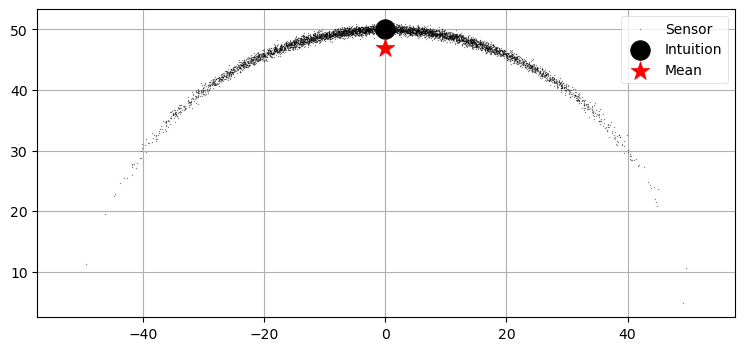

In [3]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt

N = 5000
a = np.pi/2. + (randn(N) * 0.35)
r = 50.0     + (randn(N) * 0.4)
xs = r * np.cos(a)
ys = r * np.sin(a)

plt.scatter(xs, ys, label='Sensor', color='k', 
            alpha=0.4, marker='.', s=1)
xmean, ymean = sum(xs) / N, sum(ys) / N
plt.scatter(0, 50, c='k', marker='o', s=200, label='Intuition')
plt.scatter(xmean, ymean, c='r', marker='*', s=200, label='Mean')
plt.axis('equal')
plt.legend();

We can see that out intuition failed us because the nonlinearity of the problem forced all of the errors to be biased in one direction. This bias, over many iterations, can cause the Kalman filter to diverge. Even if it doesn't diverge the solution will not be optimal. Linear approximations applied to nonlinear problems yields inaccurate results.

可以看到，直觉在这里失灵了，原因是问题的非线性把所有误差都推向同一侧。多次迭代后，这种偏置会使卡尔曼滤波器发散；即使不发散，得到的解也不是最优的。把线性近似套用到非线性问题上，结果就是不准确。


## The Effect of Nonlinear Functions on Gaussians

## 非线性函数对高斯分布的影响

Gaussians are not closed under an arbitrary nonlinear function. Recall the equations of the Kalman filter - at each evolution we pass the Gaussian representing the state through the process function to get the Gaussian at time $k$. Our process function was always linear, so the output was always another Gaussian.  Let's look at that on a graph. I will take an arbitrary Gaussian and pass it through the function $f(x) = 2x + 1$ and plot the result. We know how to do this analytically, but let's use sampling. I will generate 500,000 points with a normal distribution, pass them through $f(x)$, and plot the results. I do it this way because the next example will be nonlinear, and we will have no way to compute this analytically.

在任意非线性函数下，高斯分布的闭合性并不成立。回想卡尔曼滤波器的方程：每一次迭代，我们都把表示状态的高斯通过过程函数传递，得到时刻 $k$ 的高斯。我们的过程函数始终是线性的，所以输出始终还是高斯。用图来看一下：取任意一个高斯，把它通过函数 $f(x) = 2x + 1$，再画出结果。我们知道如何解析地求出它，但这里用采样来演示——生成 500,000 个服从正态分布的点，通过 $f(x)$，再画出结果。之所以用采样，是因为下一个例子是非线性的，无法解析计算。


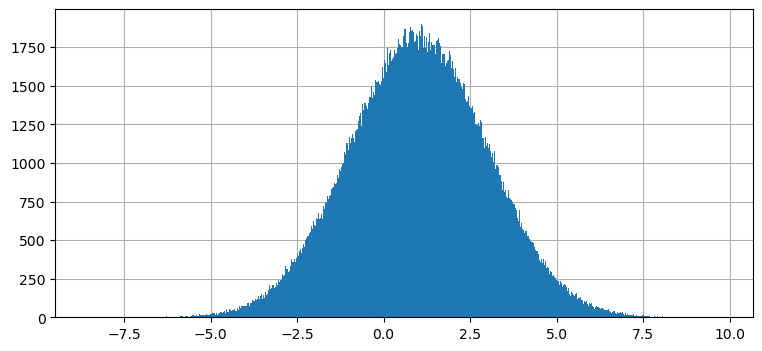

In [4]:
from numpy.random import normal

data = normal(loc=0., scale=1., size=500000)
plt.hist(2*data + 1, 1000);

This is an unsurprising result. The result of passing the Gaussian through $f(x)=2x+1$ is another Gaussian centered around 1. Let's look at the input, nonlinear function, and output at once.

这个结果并不意外。把一个高斯通过 $f(x)=2x+1$，结果仍是高斯，只是中心移到了 1。我们同时看到输入、非线性函数和输出。


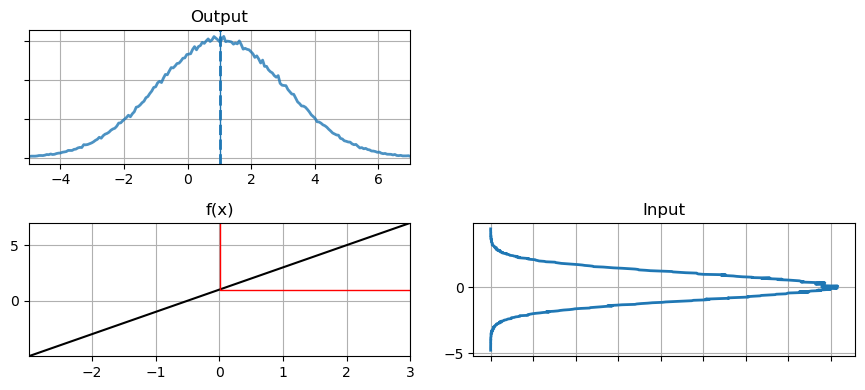

In [5]:
from kf_book.book_plots import set_figsize, figsize
from kf_book.nonlinear_plots import plot_nonlinear_func

def g1(x):
    return 2*x+1

plot_nonlinear_func(data, g1)

> I explain how to plot Gaussians, and much more, in the Notebook *Computing_and_Plotting_PDFs* in the 
Supporting_Notebooks folder. You can also read it online [here](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/Supporting_Notebooks/Computing_and_plotting_PDFs.ipynb)[1]

> 我在 Supporting_Notebooks 文件夹中的 Notebook *Computing_and_Plotting_PDFs* 中解释了如何绘制高斯曲线等等。你也可以在线阅读[这里](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in Python/blob/master/Supporting_Notebooks/Computing_and_plotting_PDFs.ipynb)[1]

The plot labeled 'Input' is the histogram of the original data. This is passed through the  function $f(x)=2x+1$ which is displayed in the chart on the bottom left. The red lines shows how one value, $x=0$ is passed through the function. Each value from input is passed through in the same way to the output function on the right. For the output I computed the mean by taking the average of all the points, and drew the results with the dotted blue line. A solid blue line shows the actual mean for the point $x=0$. The output looks like a Gaussian, and is in fact a Gaussian. We can see that the variance in the output is larger than the variance in the input, and the mean has been shifted from 0 to 1, which is what we would expect given the transfer function $f(x)=2x+1$ The $2x$ affects the variance, and the $+1$ shifts the mean The computed mean, represented by the dotted blue line, is nearly equal to the actual mean. If we used more points in our computation we could get arbitrarily close to the actual value.

标有“输入”的图是原始数据的直方图。它被通过函数 $f(x)=2x+1$，该函数显示在左下角。红线表示某个值 $x=0$ 是如何被传递的。输入中的每个值都以相同方式传递到右侧的输出。对输出，我取所有点的平均值作为估计均值，用蓝色虚线画出；蓝色实线则是点 $x=0$ 的真实均值。输出看起来像高斯，实际上也确实如此。可以看到输出的方差大于输入的方差，均值也从 0 移到了 1——这正是把函数 $f(x)=2x+1$ 作用上去的结果：$2x$ 改变方差，$+1$ 平移均值。计算出的均值（蓝色虚线）几乎等于真实均值；如果使用更多点，还可以任意逼近真实值。

Now let's look at a nonlinear function and see how it affects the probability distribution.

现在让我们看一个非线性函数，看看它如何影响概率分布。


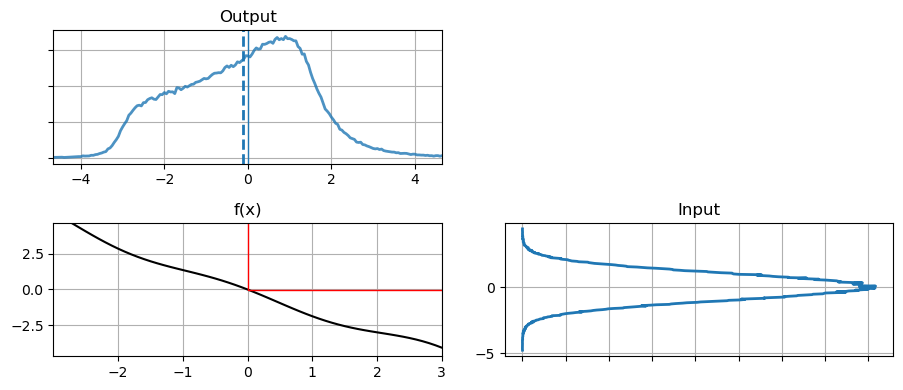

In [6]:
def g2(x):
    return (np.cos(3*(x/2 + 0.7))) * np.sin(0.3*x) - 1.6*x

plot_nonlinear_func(data, g2)

This result may be somewhat surprising to you. The function looks "fairly" linear, but the probability distribution of the output is completely different from a Gaussian.  Recall the equations for multiplying two univariate Gaussians:

这个结果也许会让你有些意外。该函数看起来“相当”接近线性，但输出的概率分布与高斯分布完全不同。回想一下两个单变量高斯相乘的公式：

$$\begin{aligned}
\mu &=\frac{\sigma_1^2 \mu_2 + \sigma_2^2 \mu_1} {\sigma_1^2 + \sigma_2^2} \\
\sigma &= \frac{1}{\frac{1}{\sigma_1^2} + \frac{1}{\sigma_2^2}}
\end{aligned}$$

These equations do not hold for non-Gaussians, and certainly do not hold for the probability distribution shown in the 'Output' chart above. 

这些公式只适用于高斯分布，对非高斯分布并不成立，自然也不适用于上面“Output”图中显示的概率分布。

Here's another way to look at the same data as scatter plots.

这是查看与散点图相同的数据的另一种方法。


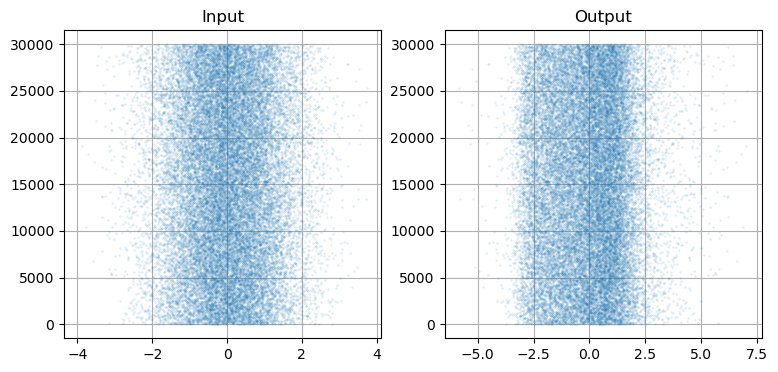

In [7]:
N = 30000
plt.subplot(121)
plt.scatter(data[:N], range(N), alpha=.1, s=1.5)
plt.title('Input')
plt.subplot(122)
plt.title('Output')
plt.scatter(g2(data[:N]), range(N), alpha=.1, s=1.5);

The original data is clearly Gaussian, but the data passed through `g2(x)` is no longer normally distributed. There is a thick band near -3, and the points are unequally distributed on either side of the band. If you compare this to the pdf labelled 'output' in the previous chart you should be able to see how the pdf shape matches the distribution of `g(data)`.

原始数据显然是高斯分布，但经 $g(x)$ 变换后的数据不再服从正态分布：$x=-3$ 附近出现一条密集的带，带两侧的点分布并不均匀。把它与上图中标记为“output”的概率密度函数对比，你应该能看出概率密度的形状与 $g(data)$ 的分布如何对应。

Think of what this implies for the Kalman filter algorithm of the previous chapter. All of the equations assume that a Gaussian passed through the process function results in another Gaussian. If this is not true then all of the assumptions and guarantees of the Kalman filter do not hold. Let's look at what happens when we pass the output back through the function again, simulating the next step time step of the Kalman filter.

想一想这对上一章的卡尔曼滤波器算法意味着什么。所有方程都建立在“高斯通过过程函数后仍是高斯”这一假设之上。一旦该假设不成立，卡尔曼滤波器的全部前提与保证也就随之失效。再看看把输出再次送回函数会发生什么，以此模拟卡尔曼滤波器的下一个时间步。


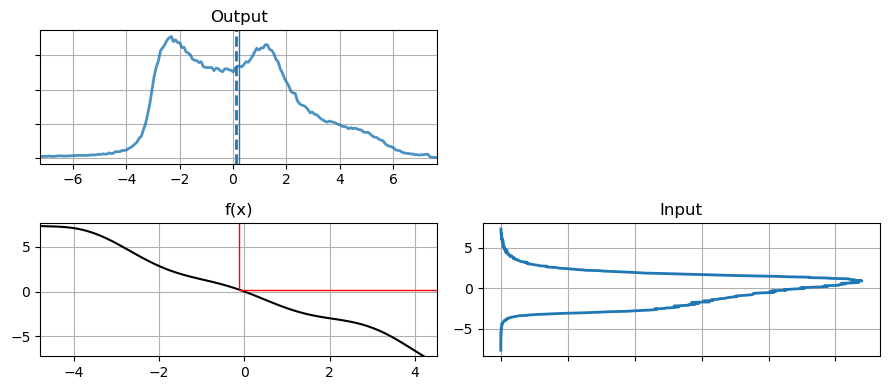

In [8]:
y = g2(data)
plot_nonlinear_func(y, g2)

As you can see the probability function is further distorted from the original Gaussian. However, the graph is still somewhat symmetric around x=0, let's see what the mean is.

如你所见，概率分布相对原始高斯进一步失真。不过该图在 $x=0$ 附近还算对称，我们来看看均值是多少。


In [9]:
print('input  mean, variance: %.4f, %.4f' % 
      (np.mean(data), np.var(data)))
print('output mean, variance: %.4f, %.4f' % 
      (np.mean(y), np.var(y)))

input  mean, variance: 0.0023, 1.0001
output mean, variance: -0.1285, 2.4044


Let's compare that to the linear function that passes through (-2,3) and (2,-3), which is very close to the nonlinear function we have plotted. Using the equation of a line we have

让我们将其与通过 (-2,3) 和 (2,-3) 的线性函数进行比较，后者与我们绘制的非线性函数非常接近。使用直线方程我们有

$$m=\frac{-3-3}{2-(-2)}=-1.5$$


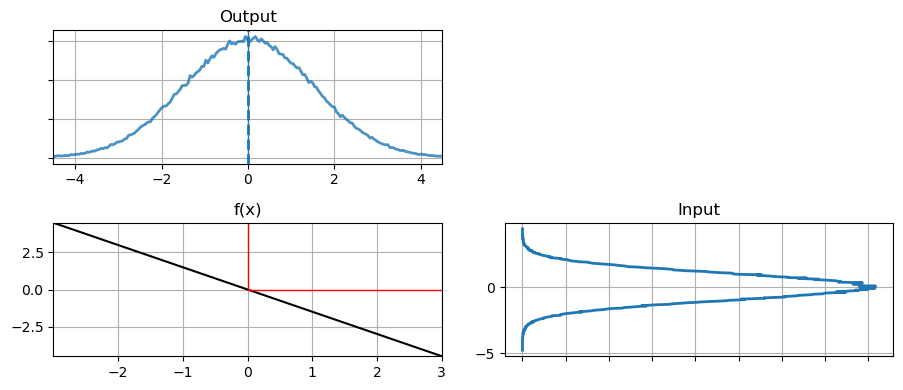

output mean, variance: -0.0035, 2.2502


In [10]:
def g3(x): 
    return -1.5 * x

plot_nonlinear_func(data, g3)
out = g3(data)
print('output mean, variance: %.4f, %.4f' % 
      (np.mean(out), np.var(out)))

Although the shapes of the output are very different, the mean and variance of each are almost the same. This may lead us to reasoning that perhaps we can ignore this problem if the nonlinear equation is 'close to' linear. To test that, we can iterate several times and then compare the results.

尽管输出的形状差别很大，但两者的均值和方差几乎相同。这容易让人推想：如果非线性方程“接近”线性，或许可以忽略这个问题。为了检验这一点，我们可以多迭代几次再比较结果。


In [11]:
out = g3(data)
out2 = g2(data)

for i in range(10):
    out = g3(out)
    out2 = g2(out2)
print('linear    output mean, variance: %.4f, %.4f' % 
      (np.average(out), np.std(out)**2))
print('nonlinear output mean, variance: %.4f, %.4f' % 
      (np.average(out2), np.std(out2)**2))

linear    output mean, variance: -0.2029, 7482.3770
nonlinear output mean, variance: -9.5987, 30498.2464


Unfortunately the nonlinear version is not stable. It drifted significantly from the mean of 0, and the variance is half an order of magnitude larger.

可惜非线性版本并不稳定：它的均值明显偏离 0，方差也大了将近半个数量级。

I minimized the issue by using a function that is quite close to a straight line. What happens if the function is $y(x)=-x^2$?

我特意选了一个非常接近直线的函数来弱化这个问题。如果换成 $y(x)=-x^2$ 又会怎样？


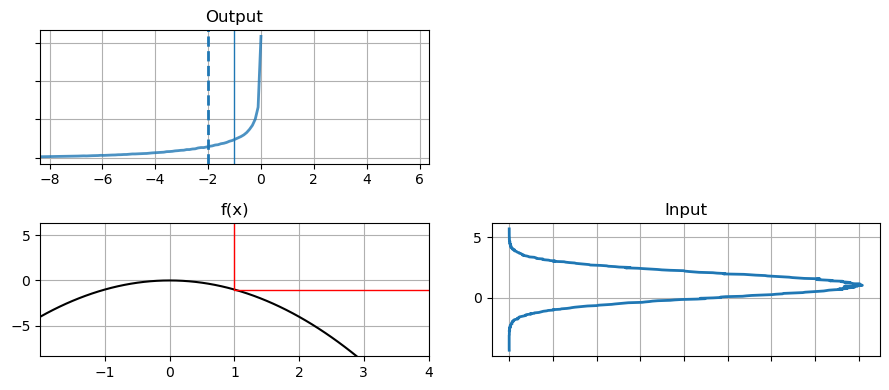

In [12]:
def g3(x): 
    return -x*x

data = normal(loc=1, scale=1, size=500000)
plot_nonlinear_func(data, g3)

Despite the curve being smooth and reasonably straight at $x=1$ the probability distribution of the output doesn't look anything like a Gaussian and the computed mean of the output is quite different than the value computed directly. This is not an unusual function - a ballistic object moves in a parabola, and this is the sort of nonlinearity your filter will need to handle. If you recall we've tried to track a ball and failed miserably. This graph should give you insight into why the filter performed so poorly.

尽管曲线在 $x=1$ 处平滑且相当接近直线，但输出的概率分布看起来并不像高斯，而且输出的计算均值与直接算出的值相差很大。这并非什么离奇的函数——抛体沿抛物线运动，正是你的滤波器必须处理的那类非线性。还记得我们尝试跟踪球却失败了吗？这张图应当能让你明白滤波器为何表现如此糟糕。


## A 2D Example

## 一个二维示例

It is hard to look at probability distributions and reason about what will happen in a filter. So let's think about tracking an aircraft with radar. The estimate may have a covariance that looks like this:

只看概率分布很难推断滤波器中会发生什么。因此，改用一个用雷达跟踪飞机的例子。估计值的协方差可能如下所示：


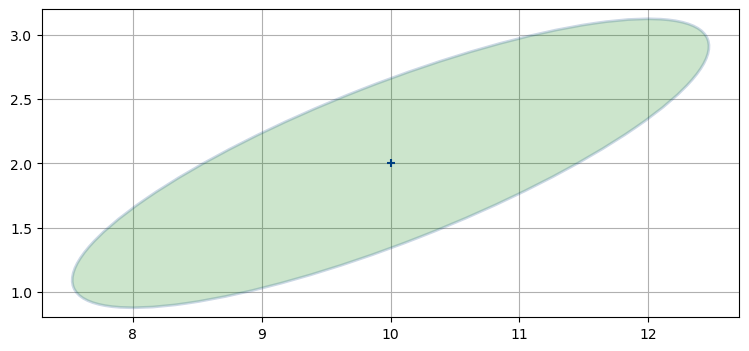

In [13]:
import kf_book.nonlinear_internal as nonlinear_internal

nonlinear_internal.plot1()

What happens when we try to linearize this problem? The radar gives us a range to the aircraft. Suppose the radar is directly under the aircraft (x=10) and the next measurement states that the aircraft is 3 miles away (y=3). The positions that could match that measurement form a circle with radius 3 miles, like so.

当我们尝试线性化这个问题时会发生什么？雷达给出的是飞机到雷达的距离。假设雷达位于飞机正下方 (x=10)，下一次测量表明飞机距离 3 英里 (y=3)。所有与该测量相符的位置构成一个半径 3 英里的圆，如图所示。


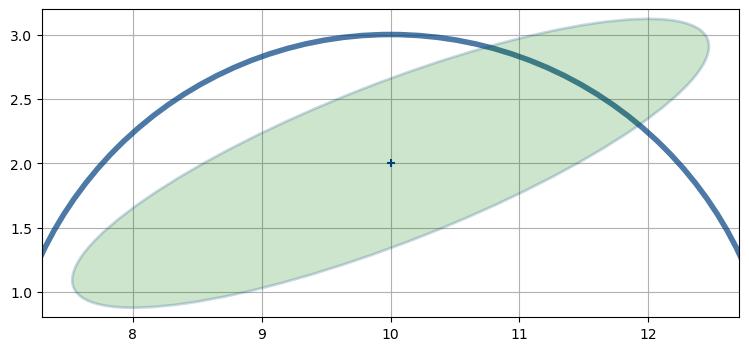

In [14]:
nonlinear_internal.plot2()

We can see by inspection that the probable position of the aircraft is somewhere near x=11.4, y=2.7 because that is where the covariance ellipse and range measurement overlap. But the range measurement is nonlinear so we have to linearize it. We haven't covered this material yet, but the Extended Kalman filter will linearize at the last position of the aircraft - (10,2). At x=10 the range measurement has y=3, and so we linearize at that point.

仔细观察可知，飞机的可能位置在 x=11.4、y=2.7 附近，因为那里正是协方差椭圆与距离测量相交之处。但距离测量是非线性的，所以必须加以线性化。这部分内容我们还没讲到，但扩展卡尔曼滤波器会在飞机上一次的位置处线性化——即 (10,2)。在 x=10 处，距离测量给出 y=3，因此我们就在该点线性化。


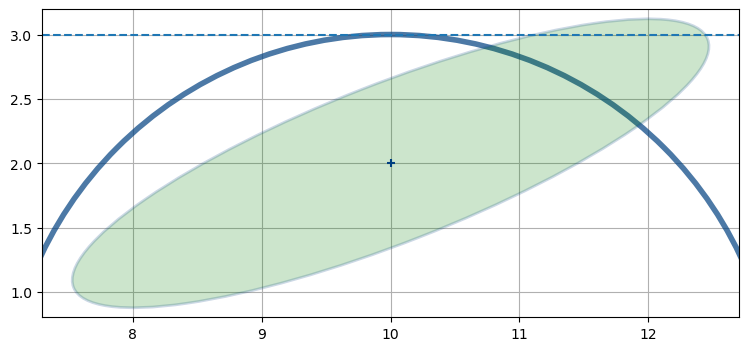

In [15]:
nonlinear_internal.plot3()

Now we have a linear representation of the problem (literally a straight line) which we can solve. Unfortunately you can see that the intersection of the line and the covariance ellipse is a long way from the actual aircraft position.

这样我们就得到了问题的线性表示（字面上就是一条直线）。遗憾的是可以看到，这条直线与协方差椭圆的交点离飞机实际位置很远。


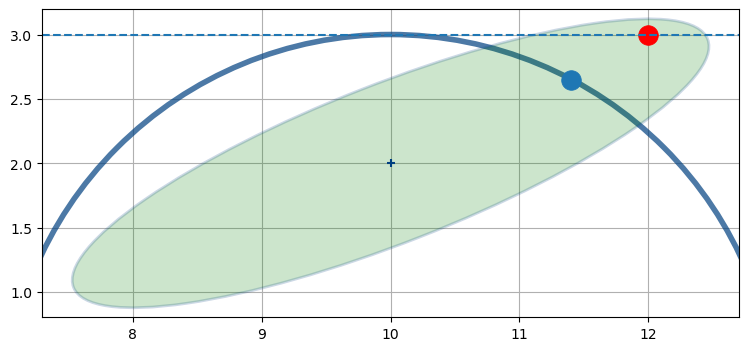

In [16]:
nonlinear_internal.plot4()

That sort of error often leads to disastrous results. The error in this estimate is large. But in the next innovation of the filter that very bad estimate will be used to linearize the next radar measurement, so the next estimate is likely to be markedly worse than this one. After only a few iterations the Kalman filter will diverge, and start producing results that have no correspondence to reality.

这类误差往往会带来灾难性后果。这次估计的误差已经很大，而在滤波器下一次更新时，这个很差的估计又会被用来线性化下一次雷达测量，于是下一次估计可能更糟。仅仅几次迭代之后，卡尔曼滤波器就会发散，开始给出与现实不符的结果。

This covariance ellipse spans miles. I exaggerated the size to illustrate the difficulties of highly nonlinear systems. In real radar tracking problems the nonlinearity is usually not that bad, but the errors will still accumulate. Other systems you might work with could have this amount of nonlinearity - this was not an exaggeration only to make a point. You will always be battling divergence when working with nonlinear systems.

这个协方差椭圆横跨数英里。我夸大了尺寸，是为了凸显高度非线性系统有多难对付。在实际雷达跟踪问题中，非线性通常没有这么严重，但误差依然会累积。而你将来遇到的某些系统，非线性程度可能真就这么强——这里并没有为了说明问题而刻意夸大。处理非线性系统时，你始终要与发散作斗争。


## The Algorithms

## 各种算法


You may be impatient to solve a specific problem, and wondering which filter to use. I will quickly survey the options. The subsequent chapters are somewhat independent of each other, and you can fruitfully skip around, though I recommend reading linearly if you truly want to master all of the material. 

你可能急着解决手头的问题，想知道该用哪种滤波器。我这里先快速梳理一下各种选项。后续各章彼此相对独立，你可以按需跳过；但若真想全面掌握，我建议按顺序通读。

The workhorses of nonlinear filters are the *linearized Kalman filter* and *extended Kalman filter* (EKF). These two techniques were invented shortly after Kalman published his paper and they have been the main techniques used since then. The flight software in airplanes, the GPS in your car or phone almost certainly use one of these techniques. 

非线性滤波的主力是线性化卡尔曼滤波器和扩展卡尔曼滤波器 (EKF)。这两种技术都在 Kalman 发表论文后不久问世，此后一直是主流做法。飞机上的飞行软件、汽车或手机里的 GPS，几乎必然会用到其中之一。

However, these techniques are extremely demanding. The EKF linearizes the differential equations at one point, which requires you to find a solution to a matrix of partial derivatives (a Jacobian). This can be difficult or impossible to do analytically. If impossible, you have to use numerical techniques to find the Jacobian, but this is expensive computationally and introduces more error into the system. Finally, if the problem is quite nonlinear the linearization leads to a lot of error being introduced in each step, and the filters frequently diverge. You cannot throw some equations into some arbitrary solver and expect to get good results. It's a difficult field for professionals. I note that most Kalman filtering textbooks merely gloss over the EKF despite it being the most frequently used technique in real world applications. 

然而这些方法要求很高。EKF 要在某一点对微分方程做线性化，这就需要求出偏导数矩阵（雅可比矩阵）。解析求解可能很难、甚至不可能；若做不到，就只能用数值方法求雅可比行列式，但那计算开销大，还会给系统引入更多误差。再者，如果问题非线性很强，线性化会在每一步引入大量误差，滤波器往往就发散了。你不能把几个方程丢给随便一个求解器，就指望得到好结果。这一领域对专业人士来说都不轻松。我注意到，大多数卡尔曼滤波教科书对 EKF 只是轻描淡写，尽管它才是实际应用中最常用的技术。

Recently the field has been changing in exciting ways. First, computing power has grown to the point that we can use techniques that were once beyond the ability of a supercomputer. These use *Monte Carlo* techniques - the computer generates thousands to tens of thousands of random points and tests all of them against the measurements. It then probabilistically kills or duplicates points based on how well they match the measurements. A point far away from the measurement is unlikely to be retained, whereas a point very close is quite likely to be retained. After a few iterations there is a clump of particles closely tracking your object, and a sparse cloud of points where there is no object.

近来，这一领域出现了令人振奋的变化。首先是算力的提升，使我们能用上过去只有超级计算机才敢想的技术。这些技术采用蒙特卡洛方法——计算机生成数千到数万个随机点，再根据测量结果逐一考察这些点。然后按各点与测量值的匹配程度，概率性地将其删除或复制：离测量值远的点不易保留，离得近的点则很可能保留下来。迭代几次之后，就会有一团粒子紧紧跟着被跟踪目标，而别处只剩稀疏的点云。

This has two benefits. First, the algorithm is robust even for extremely nonlinear problems. Second, the algorithm can track arbitrarily many objects at once - some particles will match the behavior of one object, and other particles will match other objects. So this technique is often used to track automobile traffic, people in crowds, and so on. 

这样做有两个好处。第一，即便问题非线性极强，该算法依然稳健。第二，它能同时跟踪任意多个目标——一些粒子对应这个目标的行为，另一些粒子对应其他目标。因此这类技术常用于跟踪车流、人群中的行人等。

The costs should be clear. It is computationally expensive to test tens of thousands of points for every step in the filter. But modern CPUs are very fast, and this is a good problem for GPUs because the part of the algorithm is parallelizable. Another cost is that the answer is not mathematical. With a Kalman filter my covariance matrix gives me important information about the amount of error in the estimate. The particle filter does not give me a rigorous way to compute this. Finally, the output of the filter is a cloud of points; I then have to figure out how to interpret it. Usually you will be doing something like taking the mean and standard deviations of the points, but this is a difficult problem. There are still many points that do not 'belong' to a tracked object, so you first have to run some sort of clustering algorithm to first find the points that seem to be tracking an object, and then you need another algorithm to produce a state estimate from those points. None of this is intractable, but it is all quite computationally expensive. 

代价也很明显。要在滤波的每一步考察数万个点，计算量很大。不过现代 CPU 很快，而且算法的一部分可以并行化，因此很适合交给 GPU。另一个代价是它给不出数学形式的解：用卡尔曼滤波器时，协方差矩阵能告诉我估计误差有多大的重要信息，而粒子滤波器没有严格的方法来计算它。此外，滤波器的输出是一片点云，我还得设法解释它。通常的做法无非是取这些点的均值和标准差之类，但这本身就是个难题：总有许多点并不“属于”被跟踪目标，所以你得先跑某种聚类算法找出看起来在跟踪目标的那些点，再用另一套算法从这些点生成状态估计。这些都不算棘手，但计算上都相当昂贵。

Finally, we have a new algorithm called the *unscented Kalman filter* (UKF). It does not require you to find analytic solutions to nonlinear equations, and yet almost always performs better than the EKF. It does well with nonlinear problems - problems where the EKF has significant difficulties. Designing the filter is extremely easy. Some will say the jury is still out on the UKF, but to my mind the UKF is superior in almost every way to the EKF. I suggest that the UKF should be the starting point for any implementation, especially if you are not a Kalman filter professional with a graduate degree in control theory. The main downside is that the UKF can be a few times slower than the EKF, but this really depends on whether the EKF solves the Jacobian analytically or numerically. If numerically the UKF is almost certainly faster. It has not been proven (and probably it cannot be proven) that the UKF always yields more accurate results than the EKF. In practice it almost always does, often significantly so. It is very easy to understand and implement, and I strongly suggest this filter as your starting point.

最后还有一种新算法，称为无迹卡尔曼滤波器 (UKF)。它无需你求非线性方程的解析解，而且几乎总比 EKF 表现更好，甚至能处理令 EKF 大伤脑筋的非线性问题。它的设计也容易得多。有人说 UKF 尚无定论，但在我看来，UKF 在几乎所有方面都胜过 EKF。我建议把 UKF 作为任何实现的起点，尤其是当你并非拥有控制理论研究生学位的卡尔曼滤波专家时。主要缺点是 UKF 可能比 EKF 慢几倍，但这取决于 EKF 究竟是用解析法还是数值法求雅可比矩阵：如果走数值法，UKF 几乎肯定更快。目前尚未证明（也许根本无法证明）UKF 的结果总比 EKF 更准确。但在实践中几乎总是如此，而且往往优势明显。它很容易理解和实现，我强烈建议你以它作为起点。


## Summary

## 总结


The world is nonlinear, but we only really know how to solve linear problems. This introduces significant difficulties for Kalman filters. We've looked at how nonlinearity affects filtering in 3 different but equivalent ways, and I've given you a brief summary of the major appoaches: the linearized Kalman filter, the extended Kalman filter, the Unscented Kalman filter, and the particle filter. 

世界是非线性的，而我们只会求解线性问题，这给卡尔曼滤波器带来很大困难。我们已经考察了非线性影响滤波的三种不同却等价的方式，也简要介绍了主要的几种方法：线性卡尔曼滤波器、扩展卡尔曼滤波器、无迹卡尔曼滤波器和粒子滤波器。

Until recently the linearized Kalman filter and EKF have been the standard way to solve these problems. They are very difficult to understand and use, and they are also potentially very unstable. 

直到不久前，线性化卡尔曼滤波器和 EKF 一直是解决这类问题的标准手段。但它们既难理解又难使用，而且可能非常不稳定。

Recent developments have offered what are to my mind superior approaches. The UKF dispenses with the need to find solutions to partial differential equations, yet it is also usually more accurate than the EKF. It is easy to use and understand. I can get a basic UKF going in a few minutes by using FilterPy. The particle filter dispenses with mathematical modeling completely in favor of a Monte Carlo technique of generating a random cloud of thousands of points. It runs slowly, but it can solve otherwise intractable problems with relative ease.

近年来的进展提供了我认为更好的办法。UKF 无需去求偏微分方程的解，却通常比 EKF 更准确，用起来也好懂。借助 FilterPy，我几分钟就能搭起一个基本可用的 UKF。粒子滤波器则彻底抛开数学建模，改用生成数千个随机点的蒙特卡洛方法。它运行缓慢，却能相对轻松地解决其他方法难以处理的问题。

I get more email about the EKF than anything else; I suspect that this is because most treatments in books, papers, and on the internet use the EKF. If your interest is in mastering the field of course you will want to learn about the EKF. But if you are just trying to get good results I point you to the UKF and particle filter first. They are much easier to implement, understand, and use, and they are typically far more stable than the EKF. 

读者来信中，问 EKF 的最多；我猜是因为书籍、论文和网上的大多数资料都在讲 EKF。如果你想精通这一领域，当然应当了解 EKF。但如果你只是想拿到好结果，我会首先向你推荐 UKF 和粒子滤波器：它们更易实现、理解和上手，而且通常比 EKF 稳定得多。

Some will quibble with that advice. A lot of recent publications are devoted to a comparison of the EKF, UKF, and perhaps a few other choices for a given problem. Do you not need to perform a similar comparison for your problem? If you are sending a rocket to Mars then of course you do. You will be balancing issues such as accuracy, round off errors, divergence, mathematical proof of correctness, and the computational effort required. I can't imagine not knowing the EKF intimately. 

有人会对这种建议不以为然：近来的许多论文都在针对具体问题比较 EKF、UKF 以及其他方案。难道你不需要为自己的问题做同样的比较吗？如果你要发射火星火箭，那当然需要——你得在精度、舍入误差、发散、正确性的数学证明以及计算量之间权衡。这种场合下，我无法想象你不熟悉 EKF。

On the other hand the UKF works spectacularly! I use it at work for real world applications. I mostly haven't even tried to implement an EKF for these applications because I can verify that the UKF is working fine. Is it possible that I might eke out another 0.2% of performance from the EKF in certain situations? Sure! Do I care? No! I completely understand the UKF implementation, it is easy to test and verify, I can pass the code to others and be confident that they can understand and modify it, and I am not a masochist that wants to battle difficult equations when I already have a working solution. If the UKF or particle filters start to perform poorly for some problem then I will turn to other techniques, but not before then. And realistically, the UKF usually provides substantially better performance than the EKF over a wide range of problems and conditions. If "really good" is good enough I'm going to spend my time working on other problems. 

反过来，UKF 表现得非常出色！我在实际工作中就用它处理真实项目。这些项目我甚至没有尝试用 EKF 实现，因为我能验证 UKF 工作正常。某些情况下，用 EKF 会不会再多榨出 0.2% 的性能？当然可能。我在意吗？不。我完全理解 UKF 的实现，它容易测试和验证，我可以把代码交给别人并相信他们能看懂、能改；再说，既然已经有可用的方案，我也没必要自找罪受。如果 UKF 或粒子滤波器在某些问题上开始表现不佳，我才会转向其他技术，否则不会。事实上，在大量问题和条件下，UKF 的性能通常都优于 EKF。既然“足够好”就够用，我更愿意把时间花在解决别的问题上。

I'm belaboring this point because in most textbooks the EKF is given center stage, and the UKF is either not mentioned at all or just given a 2 page gloss that leaves you completely unprepared to use the filter. The UKF is still relatively new, and it takes time to write new editions of books. At the time many books were written the UKF was either not discovered yet, or it was just an unproven but promising curiosity. But as I am writing this now, the UKF has had enormous success, and it needs to be in your toolkit. That is what I will spend most of my effort trying to teach you.

我之所以在意这点，是因为在多数教科书里 EKF 占据核心位置，而 UKF 要么只字不提，要么仅用两页带过，根本无法让你学会使用。UKF 问世较晚，而重写一本书需要时间：许多书成书时，UKF 要么尚未被提出，要么还只是个未经证实、却颇有前景的新事物。但到我写下这些文字时，UKF 已经取得巨大成功，理应纳入你的工具箱。这也正是我打算投入大部分篇幅去教给你的内容。


## References

## 参考文献

<A name="[1]">[1]</A> https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/Supporting_Notebooks/Computing_and_plotting_PDFs.ipynb
